# Modelos predictivos para SaleSight

### Objetivo: modelos predictivos y de ML que permitan hacer segmentación de clientes e identificación de cliente objetivo

En este jupyter notebook se exploran 5 modelos predictivos y de ML para la agrupación y segmentación de clientes para identificar el cliente objetivo del dataset escogido.

### 1. RFM: Recencia, Frecuencia y Monetario
Este modelo predictivo agrupa los clientes teniendo en cuenta la última vez que un cliente compró algo, cada cuanto lo hizo y el valor de dicha compra.

In [1]:
# Importar las librerías que se usarán
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/Users/josue/Library/Mobile Documents/com~apple~CloudDocs/Documents/Escritorio/Universidad/ingenieria_de_datos/corte_1/Proyecto/SaleSight/data/processed/processed_data.csv')

df['Date'] = pd.to_datetime(df['Date'])

# Última fecha del dataset
ultima_fecha = df['Date'].max()

# Creación del RFM
rfm = df.groupby('Customer_ID').agg({
    # Recencia (Cuándo fue la última fecha de compra del cliente vs la última transacción)
    'Date': lambda x: (ultima_fecha - x.max()).days,

    # Frecuencia (Cada cuánto compró el cliente)
    'Transaction_ID': 'count',

    # Monetario (Valor de la compra)
    'Total_Amount': 'sum'
})

rfm.columns = ['Recencia', 'Frecuencia', 'Monetario']

rfm.head()

,Recencia,Frecuencia,Monetario
Customer_ID,,,
10000.0,102,4,5007.566357
10001.0,104,5,8136.462824
10002.0,94,5,4104.013951
10003.0,227,2,2340.496447
10004.0,30,2,2356.516683


### Creación de métricas de Recencia, Frecuencia y Monetario

En este apartado se crean las métricas que definen el RFM, donde 5 es la mejor calificación y 1 la peor.

In [3]:
# Creación de scores (segmentación básica) de 1 a 5

# Scores de Recencia (R)
rfm['R_score'] = pd.qcut(rfm['Recencia'], 5, labels=[5, 4, 3, 2, 1])

# Scores de Frecuencia (F)
rfm['F_score'] = pd.qcut(rfm['Frecuencia'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])

# Scores de Monetario (M)
rfm['M_score'] = pd.qcut(rfm['Monetario'], 5, labels=[1, 2, 3, 4, 5])

rfm['RFM_scores'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str).astype(str)

rfm.head()

,Recencia,Frecuencia,Monetario,R_score,F_score,M_score,RFM_scores
Customer_ID,,,,,,,
10000.0,102,4,5007.566357,2,3,3,233
10001.0,104,5,8136.462824,2,4,5,245
10002.0,94,5,4104.013951,3,4,3,343
10003.0,227,2,2340.496447,1,1,2,112
10004.0,30,2,2356.516683,4,1,2,412


### Uso de KMeans como modelo de ML

Se escogió el uso de KMeans ya que permite utilizar un algoritmo de clustering para identificar los grupos de RFM usando las variables asociadas.

In [4]:
# Selección de variables
x = rfm[['Recencia', 'Frecuencia', 'Monetario']]

x['Recencia'] = np.log1p(x['Recencia'])
x['Frecuencia'] = np.log1p(x['Frecuencia'])
x['Monetario'] = np.log1p(x['Monetario'])

# Escalar los datos
escalador = StandardScaler()
x_escalado = escalador.fit_transform(x)

# Aplicar K-Means
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(x_escalado)

rfm.head()

/var/folders/9v/3pb_vdls4bngd87y90lcgrlh0000gn/T/ipykernel_7355/481296815.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['Recencia'] = np.log1p(x['Recencia'])
/var/folders/9v/3pb_vdls4bngd87y90lcgrlh0000gn/T/ipykernel_7355/481296815.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['Frecuencia'] = np.log1p(x['Frecuencia'])
/var/folders/9v/3pb_vdls4bngd87y90lcgrlh0000gn/T/ipykernel_7355/481296815.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try 

,Recencia,Frecuencia,Monetario,R_score,F_score,M_score,RFM_scores,Cluster
Customer_ID,,,,,,,,
10000.0,102,4,5007.566357,2,3,3,233,2
10001.0,104,5,8136.462824,2,4,5,245,2
10002.0,94,5,4104.013951,3,4,3,343,2
10003.0,227,2,2340.496447,1,1,2,112,3
10004.0,30,2,2356.516683,4,1,2,412,3


### Resumen de los clusters

En este apartado, se realiza un promedio de los datos del RFM agrupados por cluster para identificar los valores de las diferentes variables.

Aquí cabe resaltar que es mejor:

1. Menor recencia (R-)
2. Mayor frecuencia (F+)
3. Mayor monetario (M+)

In [5]:
resumen_cluster = rfm.groupby('Cluster').mean(numeric_only=True)

print(resumen_cluster)

           Recencia  Frecuencia    Monetario
Cluster                                     
0         10.137873    4.181765  5668.756913
1        171.579332    1.323909   874.052610
2         75.022010    5.062070  7386.355649
3        127.350183    2.532016  3452.249030


### Visualización de los clusters

Se realizó la visualización de los clusters como un diagrama de dispersión para comprender la relación entre las variables por cada agrupación

Los clusters se dividen de la siguiente manera:
0 = Clientes inactivos (Baja frecuencia y gasto)
1 = Clientes objetivo (Alta frecuencia y gasto)
2 = Clientes nuevos (Recientes pero con poco gasto)
3 = Clientes en riesgo (Alto gasto pero no reciente)

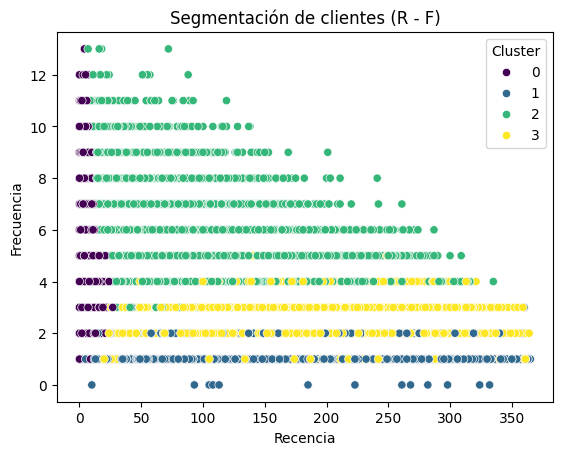

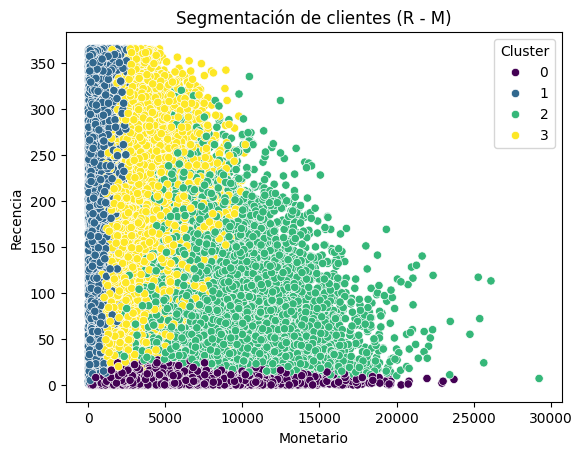

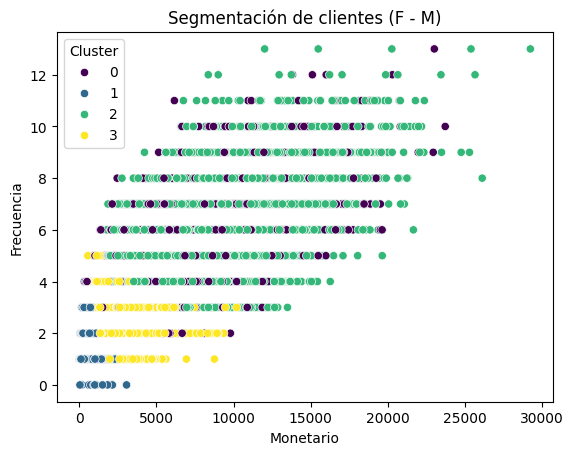

In [6]:
# Gráfico de correlación entre fecuencia y recencia
sns.scatterplot(
    x=rfm['Recencia'],
    y=rfm['Frecuencia'],
    hue=rfm['Cluster'],
    palette='viridis'
)

plt.title("Segmentación de clientes (R - F)")
plt.show()


# Gráfico de correlación entre monetario y recencia
sns.scatterplot(
    x=rfm['Monetario'],
    y=rfm['Recencia'],
    hue=rfm['Cluster'],
    palette='viridis'
)

plt.title("Segmentación de clientes (R - M)")
plt.show()


# Gráfico de correlación entre monetario y frecuencia
sns.scatterplot(
    x=rfm['Monetario'],
    y=rfm['Frecuencia'],
    hue=rfm['Cluster'],
    palette='viridis'
)

plt.title("Segmentación de clientes (F - M)")
plt.show()